In [1]:
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Dry_Bean_Dataset.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

In [4]:
df[df.duplicated()]

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
5505,33518,702.956,277.571399,154.305581,1.798842,0.831240,34023,206.582775,0.808383,0.985157,0.852377,0.744251,0.008281,0.001567,0.553909,0.996396,HOROZ
5509,33954,716.750,277.368480,156.356326,1.773951,0.825970,34420,207.922042,0.799482,0.986461,0.830549,0.749624,0.008169,0.001591,0.561936,0.996847,HOROZ
5548,38427,756.323,306.533886,160.591784,1.908777,0.851782,38773,221.193978,0.796976,0.991076,0.844174,0.721597,0.007977,0.001334,0.520702,0.993905,HOROZ
5554,38891,791.343,319.499996,156.869619,2.036723,0.871168,39651,222.525412,0.650025,0.980833,0.780422,0.696480,0.008215,0.001192,0.485085,0.987983,HOROZ
5599,40804,790.802,323.475648,163.287717,1.981016,0.863241,41636,227.932592,0.787570,0.980017,0.819931,0.704636,0.007928,0.001206,0.496512,0.983598,HOROZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7263,63408,1005.966,412.551649,196.337705,2.101235,0.879494,64200,284.136539,0.798791,0.987664,0.787385,0.688730,0.006506,0.000903,0.474348,0.996718,HOROZ
7278,63882,1004.206,411.263403,198.765453,2.069089,0.875452,64663,285.196579,0.754705,0.987922,0.796054,0.693465,0.006438,0.000918,0.480893,0.995010,HOROZ
7285,63948,996.497,412.297178,198.877557,2.073121,0.875971,64641,285.343867,0.777909,0.989279,0.809254,0.692083,0.006447,0.000912,0.478979,0.992981,HOROZ
7340,65766,1035.842,406.416622,207.242369,1.961069,0.860218,66698,289.371512,0.792295,0.986027,0.770237,0.712007,0.006180,0.000980,0.506954,0.994172,HOROZ


In [5]:
df = df.drop_duplicates()

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 13543 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13543 non-null  int64  
 1   Perimeter        13543 non-null  float64
 2   MajorAxisLength  13543 non-null  float64
 3   MinorAxisLength  13543 non-null  float64
 4   AspectRation     13543 non-null  float64
 5   Eccentricity     13543 non-null  float64
 6   ConvexArea       13543 non-null  int64  
 7   EquivDiameter    13543 non-null  float64
 8   Extent           13543 non-null  float64
 9   Solidity         13543 non-null  float64
 10  roundness        13543 non-null  float64
 11  Compactness      13543 non-null  float64
 12  ShapeFactor1     13543 non-null  float64
 13  ShapeFactor2     13543 non-null  float64
 14  ShapeFactor3     13543 non-null  float64
 15  ShapeFactor4     13543 non-null  float64
 16  Class            13543 non-null  str    
dtypes: float64(14), int64(2), st

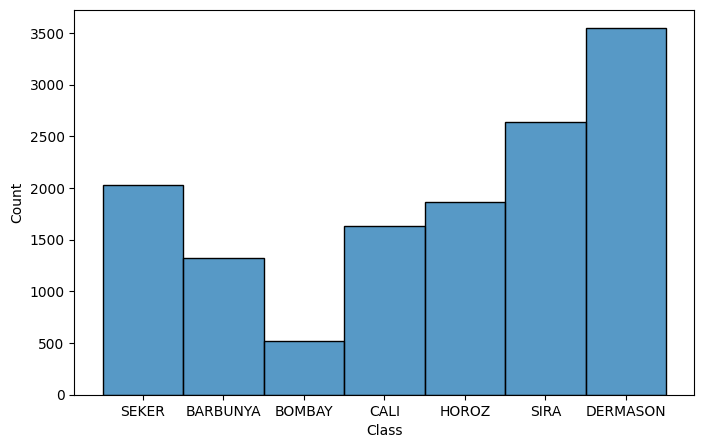

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["Class"])
plt.show()

In [8]:
X = df.drop("Class", axis = 1).values
y = df["Class"].values

In [9]:
X.shape

(13543, 16)

In [10]:
y.shape

(13543,)

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
le = LabelEncoder()

In [13]:
y = le.fit_transform(y)

In [14]:
y

array([5, 5, 5, ..., 3, 3, 3], shape=(13543,))

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
scaler = StandardScaler()

In [19]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test,  dtype=torch.long)

In [21]:
from torch import nn

In [22]:
class MultiClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_stack_layer = nn.Sequential(
            nn.Linear(16,32),
            nn.ReLU(),
            nn.Linear(32,32),
            nn.ReLU(),
            nn.Linear(32,7)
        )

    def forward(self, x):
        return self.linear_stack_layer(x)

In [23]:
torch.manual_seed(23)

In [24]:
from torchmetrics.classification import MulticlassAccuracy

In [25]:
accuracy = MulticlassAccuracy(num_classes=7)

In [26]:
model = MultiClassifier()

In [27]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model.parameters(), lr = 0.003)

In [28]:
epochs = 501

for epoch in range(epochs):
    model.train()

    logits = model(X_train)
    loss = loss_fn(logits, y_train)

    pred = torch.softmax(logits, dim=1).argmax(dim=1)
    acc = accuracy(pred, y_train).item() * 100

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()

    with torch.inference_mode():

        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)

        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        test_acc = accuracy(test_pred, y_test).item() * 100

    if epoch % 20 == 0:
        print(f"Epoch: {epoch}, Loss: {loss:.5f}, Accuracy: {acc:.3f}, Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.3f}")

Epoch: 0, Loss: 1.97241, Accuracy: 14.286, Test Loss: 1.94369, Test Accuracy: 14.286
Epoch: 20, Loss: 1.20654, Accuracy: 67.877, Test Loss: 1.15808, Test Accuracy: 69.439
Epoch: 40, Loss: 0.55437, Accuracy: 86.460, Test Loss: 0.53879, Test Accuracy: 85.715
Epoch: 60, Loss: 0.33550, Accuracy: 90.454, Test Loss: 0.33844, Test Accuracy: 89.389
Epoch: 80, Loss: 0.26273, Accuracy: 92.172, Test Loss: 0.26617, Test Accuracy: 91.904
Epoch: 100, Loss: 0.22986, Accuracy: 93.039, Test Loss: 0.23403, Test Accuracy: 92.545
Epoch: 120, Loss: 0.21602, Accuracy: 93.421, Test Loss: 0.21854, Test Accuracy: 92.951
Epoch: 140, Loss: 0.20842, Accuracy: 93.550, Test Loss: 0.20994, Test Accuracy: 93.214
Epoch: 160, Loss: 0.20303, Accuracy: 93.639, Test Loss: 0.20489, Test Accuracy: 93.297
Epoch: 180, Loss: 0.19893, Accuracy: 93.791, Test Loss: 0.20102, Test Accuracy: 93.342
Epoch: 200, Loss: 0.19553, Accuracy: 93.881, Test Loss: 0.19782, Test Accuracy: 93.289
Epoch: 220, Loss: 0.19259, Accuracy: 93.991, Test

In [29]:
from torchmetrics.classification import MulticlassConfusionMatrix

In [30]:
cm = MulticlassConfusionMatrix(num_classes=7)

In [31]:
matrix = cm(test_pred, y_test)

In [36]:
matrix

tensor([[217,   0,  21,   0,   1,   1,   4],
        [  0,  92,   0,   0,   0,   0,   0],
        [ 11,   0, 305,   0,   6,   0,   2],
        [  0,   0,   0, 662,   1,  10,  40],
        [  1,   0,   6,   3, 339,   0,   7],
        [  3,   0,   1,  12,   0, 420,  10],
        [  2,   0,   2,  43,   8,   4, 475]])

In [37]:
from torchmetrics.utilities.plot import plot_confusion_matrix

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

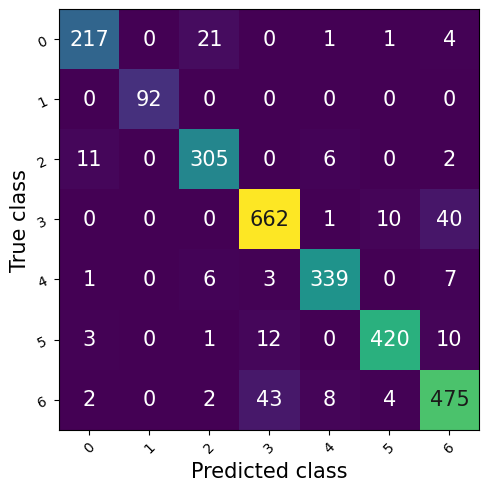

In [38]:
plot_confusion_matrix(matrix)

In [39]:
from pathlib import Path

In [40]:
MODEL_PATH = Path("DryBeanMC")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "DryBeanClassifier.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)